# **<u> TP n°6 : Tableau de bord <u>**

## Imen MILOUDI

### M1 MAS DS


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

J'ai décidé d'étudier la table "absences_enrichies" afin de concevoir mon tableau de bord sur les statistiques d'absentéisme.

In [3]:
absences_enrichies = pd.read_csv('/Users/imenmiloudi/Downloads/Rendu_TP6_Imen_Miloudi/absences_enrichies.csv')
print("Table chargée :")
print(f"- Abscences enrichies: {len(absences_enrichies)} lignes")

absences_enrichies['debut'] = pd.to_datetime(absences_enrichies['debut'], errors='coerce')
if absences_enrichies['fin'] is not None:
    absences_enrichies['fin'] = pd.to_datetime(absences_enrichies['fin'], errors='coerce')
else:
    absences_enrichies['fin'] = pd.NaT

absences_enrichies['mois'] = absences_enrichies['debut'].dt.to_period('M').dt.to_timestamp()
absences_enrichies['annee'] = absences_enrichies['debut'].dt.year
absences_enrichies.head()

Table chargée :
- Abscences enrichies: 2586 lignes


,id,id_contrat,debut,fin,jours_ouvres,code,libellé_absence,libellé_contrat,famille,type_absence,type_contrat,nom,prénom,catégorie,age,mois,annee
0,5,5,2024-10-07,2024-10-13,5,MAL,Maladie,Chargé des affaires médicales (planning pratic...,Maladie,Maladie,cdi,Youssouf,Miguel,Administratif,48.964384,2024-10-01,2024
1,5,5,2024-10-26,2024-11-02,4,MAL,Maladie,Chargé des affaires médicales (planning pratic...,Maladie,Maladie,cdi,Youssouf,Miguel,Administratif,48.964384,2024-10-01,2024
2,5,5,2025-04-09,2025-04-15,5,MAL,Maladie,Chargé des affaires médicales (planning pratic...,Maladie,Maladie,cdi,Youssouf,Miguel,Administratif,48.964384,2025-04-01,2025
3,5,5,2025-05-30,2025-06-02,2,MAL,Maladie,Chargé des affaires médicales (planning pratic...,Maladie,Maladie,cdi,Youssouf,Miguel,Administratif,48.964384,2025-05-01,2025
4,5,5,2025-06-08,2025-06-11,2,MAL,Maladie,Chargé des affaires médicales (planning pratic...,Maladie,Maladie,cdi,Youssouf,Miguel,Administratif,48.964384,2025-06-01,2025


# Histogramme des types d'absences :

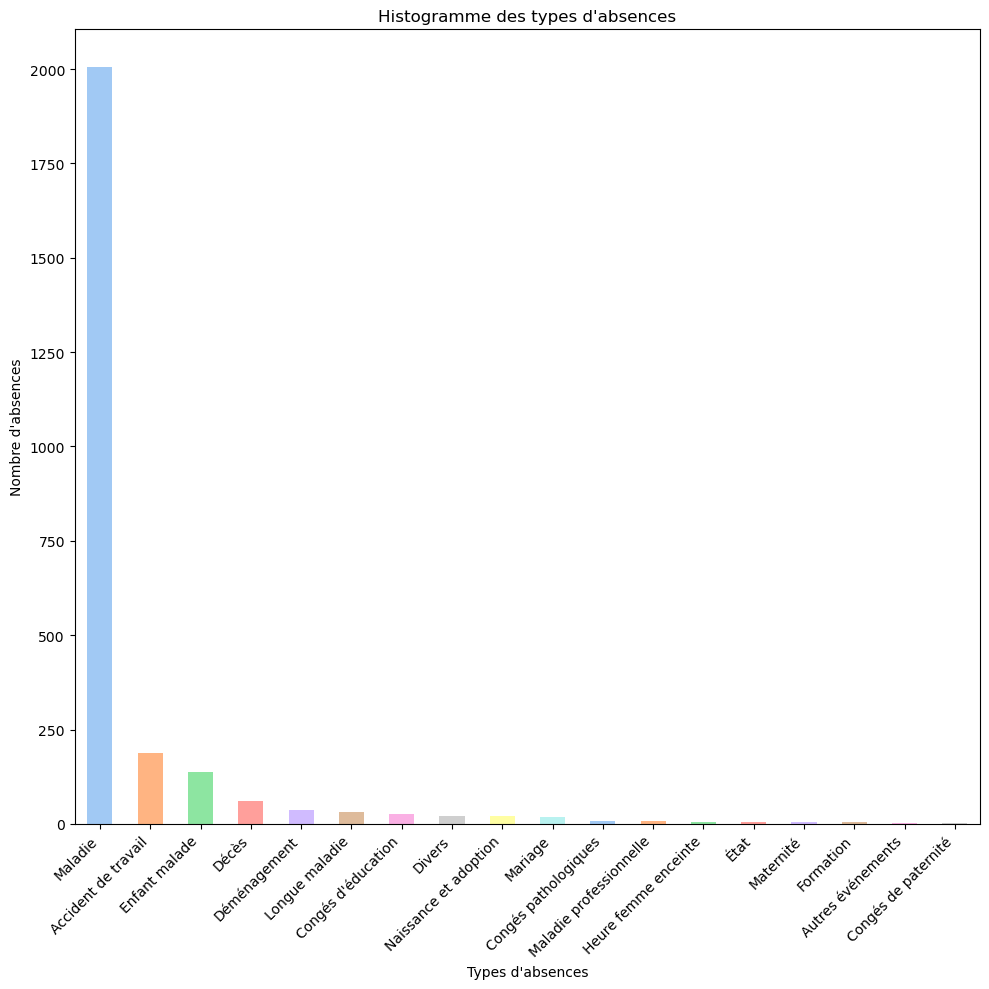

In [4]:
abs_nb = absences_enrichies['type_absence'].value_counts()

colors  = sns.color_palette("pastel", len(abs_nb))

plt.figure(figsize=(10, 10))
abs_nb.plot(kind = 'bar', color = colors)

plt.title("Histogramme des types d'absences")
plt.xlabel("Types d'absences")
plt.ylabel("Nombre d'absences")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

On voit qu'on a une grande majorité d'arrêts maladie, et les absences pour congé paternité sont les moins nombreuses.

# Statistiques sur les durées d'arrêts :

In [5]:
absences_enrichies['jours_ouvres'].describe()

count    2586.000000
mean        5.229312
std         8.216062
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       109.000000
Name: jours_ouvres, dtype: float64

In [6]:
absences_enrichies[absences_enrichies['jours_ouvres'] == absences_enrichies['jours_ouvres'].min()]

,id,id_contrat,debut,fin,jours_ouvres,code,libellé_absence,libellé_contrat,famille,type_absence,type_contrat,nom,prénom,catégorie,age,mois,annee
10,7,7,2025-03-09,2025-03-10,1,DEME,Déménagement,Secrétaire de consultation,Événements familiaux,Déménagement,cdi,Elbaz,Mehdi,Administratif/médical,50.301370,2025-03-01,2025
34,29,29,2024-10-13,2024-10-14,1,DEME,Déménagement,Infirmier UHCD/USC,Événements familiaux,Déménagement,cdi,Dias,Léa,Soins infirmiers,61.621918,2024-10-01,2024
79,75,75,2024-09-13,2024-09-15,1,MAL,Maladie,Infirmier anesthésiste (IADE),Maladie,Maladie,cdi,Fabre,Salma,Bloc opératoire,57.747945,2024-09-01,2024
104,95,95,2025-01-31,2025-02-02,1,MAL,Maladie,Animateur EHPAD,Maladie,Maladie,cdi,Dias,Maya,Psycho-social,54.172603,2025-01-01,2025
118,98,98,2024-12-28,2024-12-30,1,MAL,Maladie,Infirmier addictologie,Maladie,Maladie,cdi,Kassabian,Sarah,Soins infirmiers,48.126027,2024-12-01,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,4308,4308,2025-05-08,2025-05-11,1,MAL,Maladie,Infirmier de bloc opératoire (IBODE),Maladie,Maladie,cdi,Traoré,Matteo,Bloc opératoire,64.309589,2025-05-01,2025
2519,4334,4334,2024-09-13,2024-09-15,1,MAL,Maladie,Neurologue,Maladie,Maladie,cdi,Derderian,Tom,Médical,42.928767,2024-09-01,2024
2545,4380,4380,2025-03-28,2025-03-30,1,MAL,Maladie,Responsable plateau d'imagerie,Maladie,Maladie,cdi,Giraud,Raphaël,Imagerie,31.213699,2025-03-01,2025
2554,4417,4417,2024-08-31,2024-09-02,1,MAL,Maladie,Secrétaire de consultation,Maladie,Maladie,cdi,Bouzid,Karim,Administratif/médical,41.454795,2024-08-01,2024


In [7]:
absences_enrichies[absences_enrichies['jours_ouvres'] == absences_enrichies['jours_ouvres'].max()]

,id,id_contrat,debut,fin,jours_ouvres,code,libellé_absence,libellé_contrat,famille,type_absence,type_contrat,nom,prénom,catégorie,age,mois,annee
779,797,797,2025-02-02,2025-07-10,109,CEDU,Congé parental d'éducation,Infirmier dialyse,Parentalité,Congés d'éducation,cdi,Garcia,Théo,Soins infirmiers,49.972603,2025-02-01,2025
1724,2794,2794,2024-08-28,2025-02-05,109,LMAL,Longue maladie,Secrétaire de pôle médical,Maladie,Longue maladie,cdd,Fabre,Lina,Administratif,31.720548,2024-08-01,2024


On voit qu'il y a eu 2586 jours d'absences au total sur la période étudiée, tous postes confondues.

En moyenne, les employés sont 5 jours ouvrés, la plus courte période d'absence est de 1 jour et la plus longue est de 109 jours, c'est Théo Garcia et Lina Fabre qui ont eu les absences les plus longues, l'un pour parentalité et l'autre pour arrêt maladie.

stats des nombres de types d'absences selon les mois voir slide 34 CM 5.


# Les mois avec le plus et le moins d'absences :

In [8]:
absences_par_mois = absences_enrichies.groupby('mois')['jours_ouvres'].sum().reset_index()

min_abs = absences_par_mois['jours_ouvres'].min()
max_abs = absences_par_mois['jours_ouvres'].max()

mois_min = absences_par_mois[absences_par_mois['jours_ouvres'] == min_abs]['mois']
mois_max = absences_par_mois[absences_par_mois['jours_ouvres'] == max_abs]['mois']

print("Mois avec le plus d'absences :")
print(mois_max)
print("avec :", max_abs, "jours d'absences")

print("Mois avec le moins d'absences :")
print(mois_min)
print("avec :", min_abs, "jours d'absences")

absences_par_mois


Mois avec le plus d'absences :
2   2024-09-01
Name: mois, dtype: datetime64[ns]
avec : 1367 jours d'absences
Mois avec le moins d'absences :
0   2024-07-01
Name: mois, dtype: datetime64[ns]
avec : 376 jours d'absences


,mois,jours_ouvres
0,2024-07-01,376
1,2024-08-01,924
2,2024-09-01,1367
3,2024-10-01,1201
4,2024-11-01,1164
5,2024-12-01,979
6,2025-01-01,1119
7,2025-02-01,895
8,2025-03-01,1049
9,2025-04-01,877


# Taux d'absentéisme global :

On considère que Taux absentéisme = $\frac{jours\_absence}{jours\_total\_travail}$

On considère que dans un mois, il y a en moyenne 21.75 jours ouvrés.

In [9]:
total_jours_absence = absences_enrichies['jours_ouvres'].sum()
total_employes = absences_enrichies['id_contrat'].nunique()

debut = absences_enrichies['mois'].min()
fin = absences_enrichies['mois'].max()
duree_etude = (fin.year - debut.year) * 12 + (fin.month - debut.month) + 1 # en mois

jour_travail_mois = 21.75

jours_total_travail = total_employes * duree_etude * jour_travail_mois
taux_absenteisme = (total_jours_absence / jours_total_travail) * 100

print("Taux d'absentéisme global :", taux_absenteisme, "%")

Taux d'absentéisme global : 5.422528575237935 %


Ce taux d'absentéisme signifie que 5% du "temps de travail" a été perdu à cause d'absences.

Sur une année on a environ $21.75 * 12 = 261 $ jours ouvrés, on a donc environ $0.05 * 261 =13,05 $ jours d'absence par salarié par an.

On peut maintenant étudier ce taux d'absentéisme par type d'absence, type de contrat, catégorie d'emploi, par periode.

## Taux d'absentéisme par contrat :

In [10]:
def taux_absenteisme_colonne(df, colonne) :
    table = (
        df.groupby(colonne).agg(jours_absence = ('jours_ouvres', 'sum'),
                                n_employes = ('id_contrat', 'nunique'),
                                n_mois = ('mois', lambda x : x.nunique())).reset_index()
    )
    
    table['jours_travail'] = (
        table['n_employes'] * table['n_mois'] * jour_travail_mois
    )
    
    table['taux_absenteisme'] = (
        table['jours_absence'] / table['jours_travail'] * 100
    )
    
    table['colonne'] = colonne
    table = table.rename(columns = {colonne : 'modalite'})
    return table[['colonne', 'modalite', 'taux_absenteisme']]

absence_contrat = taux_absenteisme_colonne(absences_enrichies, 'type_contrat')
absence_categorie = taux_absenteisme_colonne(absences_enrichies, 'catégorie')
absence_type = taux_absenteisme_colonne(absences_enrichies, 'type_absence')

table_mois = (
    absences_enrichies.groupby('mois').agg(jours_absence = ('jours_ouvres', 'sum')).reset_index()
)

table_mois['taux_absenteisme'] = (
    table_mois['jours_absence'] / (total_employes * jour_travail_mois) * 100
)

table_mois['colonne'] = 'mois'
table_mois = table_mois.rename(columns = {'mois' : 'modalite'})
absence_mois = table_mois[['colonne', 'modalite', 'taux_absenteisme']]


## Absentéisme par contrat :

In [11]:
absence_contrat

,colonne,modalite,taux_absenteisme
0,type_contrat,cdd,5.274419
1,type_contrat,cdi,5.450986


In [12]:
max_abs_contrat = absence_contrat['taux_absenteisme'].max()
contrat_max = absence_contrat[absence_contrat['taux_absenteisme'] == max_abs_contrat]['modalite']

print("Le type de contrat avec le plus haut taux d'absentéisme est :")
print(contrat_max)
print("avec un taux de :", max_abs_contrat, "%")


Le type de contrat avec le plus haut taux d'absentéisme est :
1    cdi
Name: modalite, dtype: object
avec un taux de : 5.450986297244391 %


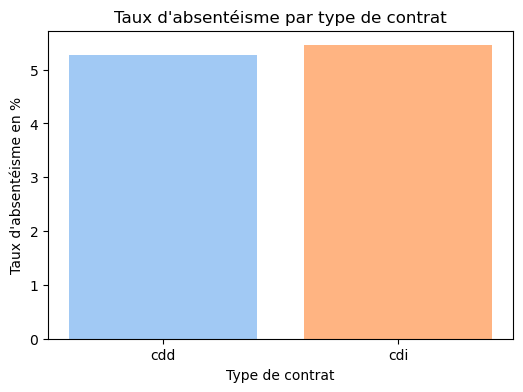

In [13]:
plt.figure(figsize = (6, 4))
plt.bar(absence_contrat['modalite'], absence_contrat['taux_absenteisme'], color = colors)

plt.xlabel('Type de contrat')
plt.ylabel("Taux d'absentéisme en %")
plt.title("Taux d'absentéisme par type de contrat")

plt.show()

Les taux d'absentéisme dans ces 2 types de contrats sont assez proches mais légèrement plus élevés chez les CDI, cela peut être du au fait que les CDI sont peut-être plus âgés et qu'ils ont besoin de plus d'arrêt maladie, il pourrait donc être intéressant d'étudier les absences selon l'âge et le contrat ainsi que la raison de ces absences. 

## Absentéisme par catégorie de poste :

In [14]:
absence_categorie

,colonne,modalite,taux_absenteisme
0,catégorie,Administratif,5.698309
1,catégorie,Administratif/médical,7.320955
2,catégorie,Biomédical,5.449127
3,catégorie,Bloc opératoire,5.681774
4,catégorie,Direction,7.356322
5,catégorie,Hygiène/Hôtellerie,5.977011
6,catégorie,Imagerie,5.176433
7,catégorie,Information médicale,5.087271
8,catégorie,Juridique,10.344828
9,catégorie,Laboratoire,3.748895


In [15]:
max_abs_categorie = absence_categorie['taux_absenteisme'].max()
categorie_max = absence_categorie[absence_categorie['taux_absenteisme'] == max_abs_categorie]['modalite']

min_abs_categorie = absence_categorie['taux_absenteisme'].min()
categorie_min = absence_categorie[absence_categorie['taux_absenteisme'] == min_abs_categorie]['modalite']


In [16]:
print("La catégorie d'emploi avec le plus haut taux d'absentéisme est :")
print(categorie_max)
print("avec un taux de :", max_abs_categorie, "%")

La catégorie d'emploi avec le plus haut taux d'absentéisme est :
14    Psycho-social
Name: modalite, dtype: object
avec un taux de : 11.75950486295314 %


In [17]:
print("La catégorie d'emploi avec le plus faible taux d'absentéisme est :")
print(categorie_min)
print("avec un taux de :", min_abs_categorie, "%")


La catégorie d'emploi avec le plus faible taux d'absentéisme est :
9    Laboratoire
Name: modalite, dtype: object
avec un taux de : 3.748894783377542 %


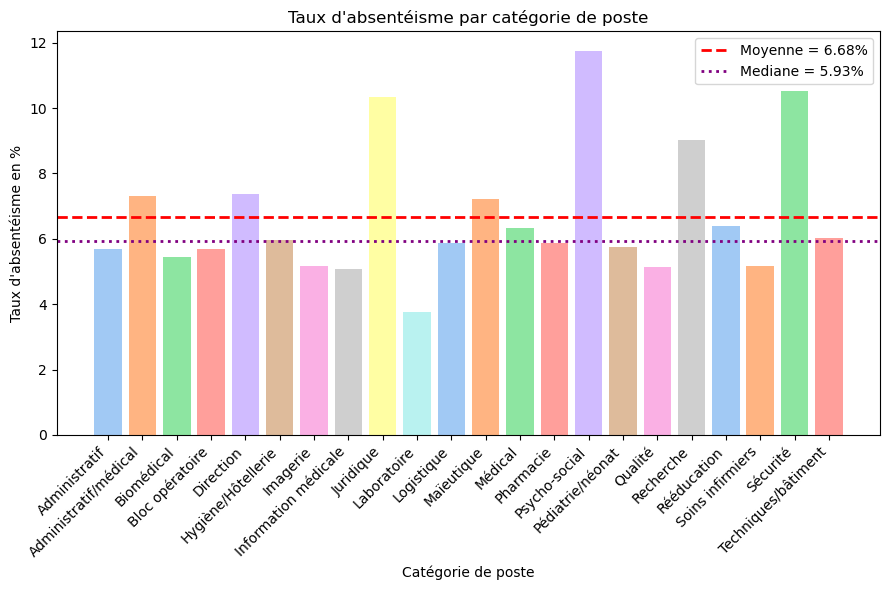

In [18]:
plt.figure(figsize = (9, 6))
plt.bar(absence_categorie['modalite'], absence_categorie['taux_absenteisme'], color = colors)

moyenne_cat = absence_categorie['taux_absenteisme'].mean()
mediane_cat = absence_categorie['taux_absenteisme'].median()

plt.axhline(moyenne_cat, linestyle = '--', linewidth = 2, label = f"Moyenne = {moyenne_cat:.2f}%", color = 'red')

plt.axhline(mediane_cat, linestyle = ':', linewidth = 2, label = f"Mediane = {mediane_cat:.2f}%", color = 'purple')

plt.xlabel("Catégorie de poste")
plt.ylabel("Taux d'absentéisme en %")
plt.title("Taux d'absentéisme par catégorie de poste")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.legend()

plt.show()

On remarque que les personnes travaillant dans les catégorie psycho-social, juridique et sécurité sont les plus absents avec un taux d'absentéisme supérieur à 10%.

Et les personnes les moins absentes sont ceux qui travaillent en laboratoire, ce sont les seuls à avoir un taux d'absentéisme inferieur à 4%.

Le taux d'absentéisme varie donc fortement selon les postes, on peut penser par exemple que les postes en sécurité ont des horaires assez décalée, ils peuvent travailler de nuit et avoir un poste assez stressant ce qui a une influence sur le taux d'absentéisme, il semble intéressant d'étudier les raisons des absences dans ces catégories avec des taux d'absences élévées.

On remarque que la médiane est légèrement plus faible que la moyenne, le taux d'absentéisme est réparti de manière légèrement asymétrique selon les types de postes, le taux d'absentéisme très élevé dans certaines catégories fait augmenter la moyenne.

## Absentéisme par type d'absence

In [19]:
absence_type

,colonne,modalite,taux_absenteisme
0,type_absence,Accident de travail,7.167845
1,type_absence,Autres événements,27.586207
2,type_absence,Congés d'éducation,22.664964
3,type_absence,Congés de paternité,20.689655
4,type_absence,Congés pathologiques,4.022989
5,type_absence,Divers,3.239289
6,type_absence,Décès,2.008592
7,type_absence,Déménagement,1.063931
8,type_absence,Enfant malade,1.365280
9,type_absence,Formation,4.597701


In [20]:
max_abs_type = absence_type['taux_absenteisme'].max()
type_max = absence_type[absence_type['taux_absenteisme'] == max_abs_type]['modalite']

min_abs_type = absence_type['taux_absenteisme'].min()
type_min = absence_type[absence_type['taux_absenteisme'] == min_abs_type]['modalite']


In [21]:
print("Le type d'absences avec le plus haut taux d'absentéisme est :")
print(type_max)
print("avec un taux de :", max_abs_type, "%")

Le type d'absences avec le plus haut taux d'absentéisme est :
11    Longue maladie
Name: modalite, dtype: object
avec un taux de : 90.39673711531331 %


In [22]:
print("Le type d'absences avec le plus faible taux d'absentéisme est :")
print(type_min)
print("avec un taux de :", min_abs_type, "%")

Le type d'absences avec le plus faible taux d'absentéisme est :
7    Déménagement
Name: modalite, dtype: object
avec un taux de : 1.0639308444951079 %


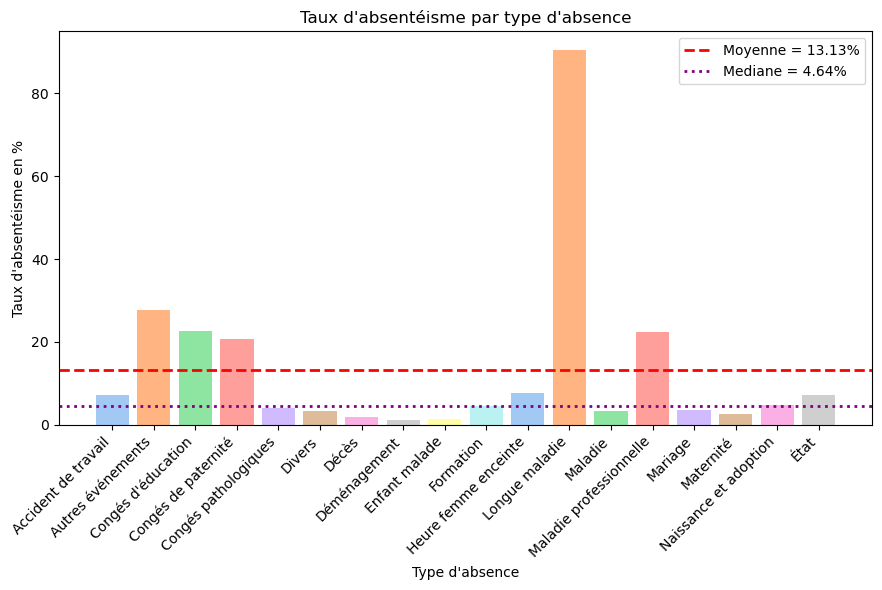

In [23]:
plt.figure(figsize = (9, 6))
plt.bar(absence_type['modalite'], absence_type['taux_absenteisme'], color = colors)

moyenne_type = absence_type['taux_absenteisme'].mean()
mediane_type = absence_type['taux_absenteisme'].median()

plt.axhline(moyenne_type, linestyle = '--', linewidth = 2, label = f"Moyenne = {moyenne_type:.2f}%", color = 'red')

plt.axhline(mediane_type, linestyle = ':', linewidth = 2, label = f"Mediane = {mediane_type:.2f}%", color = 'purple')

plt.xlabel("Type d'absence")
plt.ylabel("Taux d'absentéisme en %")
plt.title("Taux d'absentéisme par type d'absence")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.legend()

plt.show()

On remarque dans le premier histogramme, les arrêts maladie sont les plus fréquents, ils représentent la majorité des absences.

Toutefois, dans ce graphique on regarde la durée totale de chaque type  d'absences dans l'année, donc une "longue maladie" correspond à une absence de plusieurs semaines voire mois, ils sont donc moins nombreux dans le premier graphique, mais leur durée est beaucoup plus longue que tous les autres arrêts, c'est pourquoi il est intéressant d'étudier les 2 histogrammes.

Le premier nous a montré quels sont les motifs d'absence les plus fréquents, et celui-ci nous montre quels sont les motifs d'absence avec les plus grandes durées.
Les arrêts maladie courts sont donc fréquents, mais les longs arrêts maladie ont un plus gros impact sur les taux d'absence.

## Absentéisme par mois

In [24]:
absence_mois

,colonne,modalite,taux_absenteisme
0,mois,2024-07-01,2.110788
1,mois,2024-08-01,5.187150
2,mois,2024-09-01,7.674063
3,mois,2024-10-01,6.742172
4,mois,2024-11-01,6.534462
5,mois,2024-12-01,5.495909
6,mois,2025-01-01,6.281841
7,mois,2025-02-01,5.024350
8,mois,2025-03-01,5.888875
9,mois,2025-04-01,4.923301


In [25]:
max_abs_mois = absence_mois['taux_absenteisme'].max()
mois_max = absence_mois[absence_mois['taux_absenteisme'] == max_abs_mois]['modalite']

min_abs_mois = absence_mois['taux_absenteisme'].min()
mois_min = absence_mois[absence_mois['taux_absenteisme'] == min_abs_mois]['modalite']


In [26]:
print("Le mois avec le plus haut taux d'absentéisme est :")
print(mois_max)
print("avec un taux de :", max_abs_mois, "%")


Le mois avec le plus haut taux d'absentéisme est :
2   2024-09-01
Name: modalite, dtype: datetime64[ns]
avec un taux de : 7.67406284647664 %


In [27]:
print("Le mois avec le plus faible taux d'absentéisme est :")
print(mois_min)
print("avec un taux de :", min_abs_mois, "%")

Le mois avec le plus faible taux d'absentéisme est :
0   2024-07-01
Name: modalite, dtype: datetime64[ns]
avec un taux de : 2.1107883176848694 %


Ce qui confirme ce que nous avons trouvé précedemment.

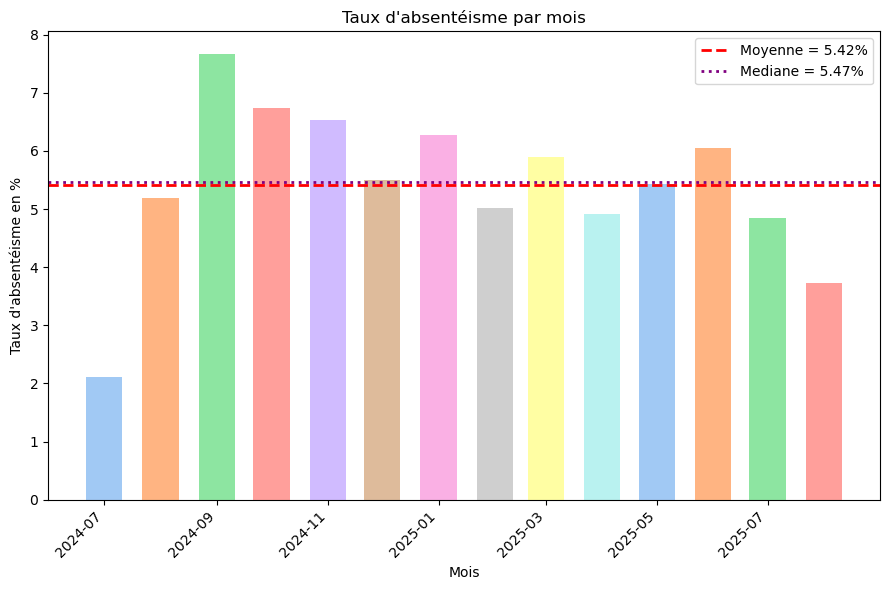

In [28]:
plt.figure(figsize = (9, 6))
plt.bar(absence_mois['modalite'], absence_mois['taux_absenteisme'], color = colors, width = 20)

moyenne_mois = absence_mois['taux_absenteisme'].mean()
mediane_mois = absence_mois['taux_absenteisme'].median()

plt.axhline(moyenne_mois, linestyle = '--', linewidth = 2, label = f"Moyenne = {moyenne_mois:.2f}%", color = 'red')

plt.axhline(mediane_mois, linestyle = ':', linewidth = 2, label = f"Mediane = {mediane_mois:.2f}%", color = 'purple')

plt.xlabel("Mois")
plt.ylabel("Taux d'absentéisme en %")
plt.title("Taux d'absentéisme par mois")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.legend()

plt.show()

On remarque que le taux d'absentéisme est supérieur à la moyenne de septembre jusqu'à janvier, cela peut être dû au fait que c'est une période où les gens tombent plus souvent malade, pour confirmer cela, il faudrait étudier les motifs d'absences selon les mois.

## Age des employés selon le type d'absences

/var/folders/p7/6d8yhyb548n9zytc57_yk00m0000gn/T/ipykernel_2421/2555447420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


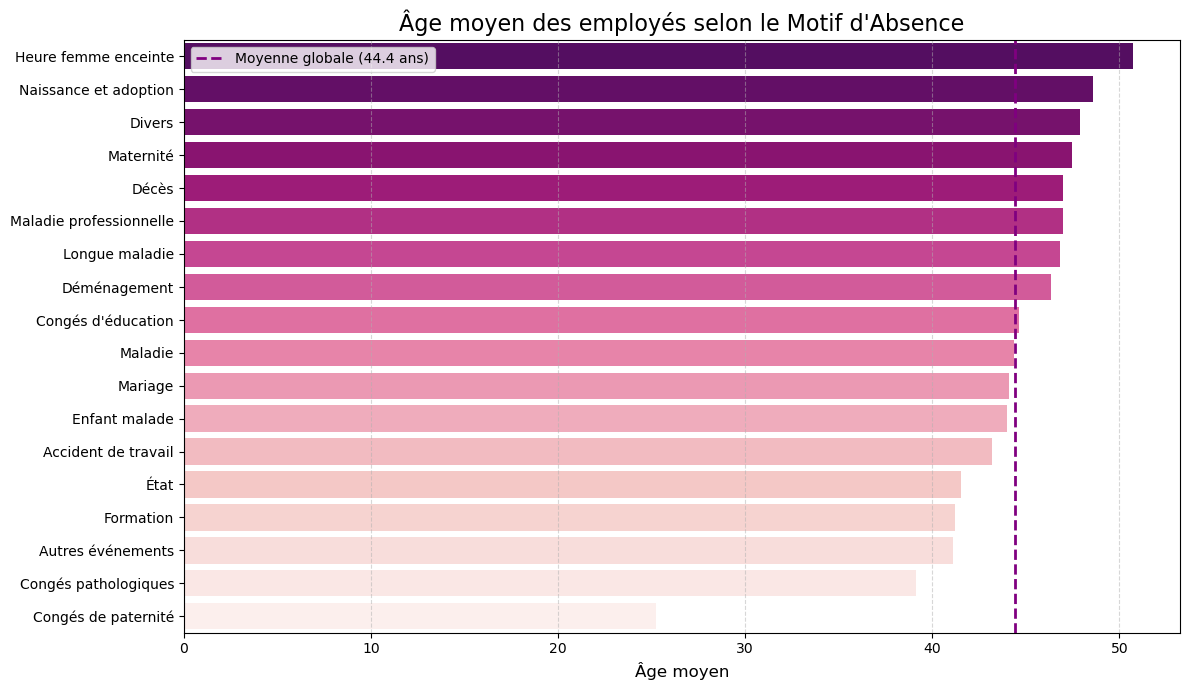

            type_absence        age
0   Heure femme enceinte  50.705936
1  Naissance et adoption  48.605205
2                 Divers  47.879726
3              Maternité  47.488767
4                  Décès  46.994341


In [68]:
age_moyen_par_type = absences_enrichies.groupby('type_absence')['age'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=age_moyen_par_type,
    x='age',
    y='type_absence',
    palette="RdPu_r")

moyenne_globale = absences_enrichies['age'].mean()
plt.axvline(moyenne_globale, color='purple', linestyle='--', linewidth=2, label=f'Moyenne globale ({moyenne_globale:.1f} ans)')

plt.title("Âge moyen des employés selon le Motif d'Absence", fontsize=16)
plt.xlabel("Âge moyen", fontsize=12)
plt.ylabel("")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(age_moyen_par_type.head(5))

On voit que pour les arrêts maladie par exemple, l'âge moyen des employés est d'environ 43 ans, ce ne sont pas les jeunes employés qui prennent le plus d'arrêts maladie.

Chez les plus jeunes employés le type d'absence le plus fréquent sont les congés paternité.

## Evolution temporelle

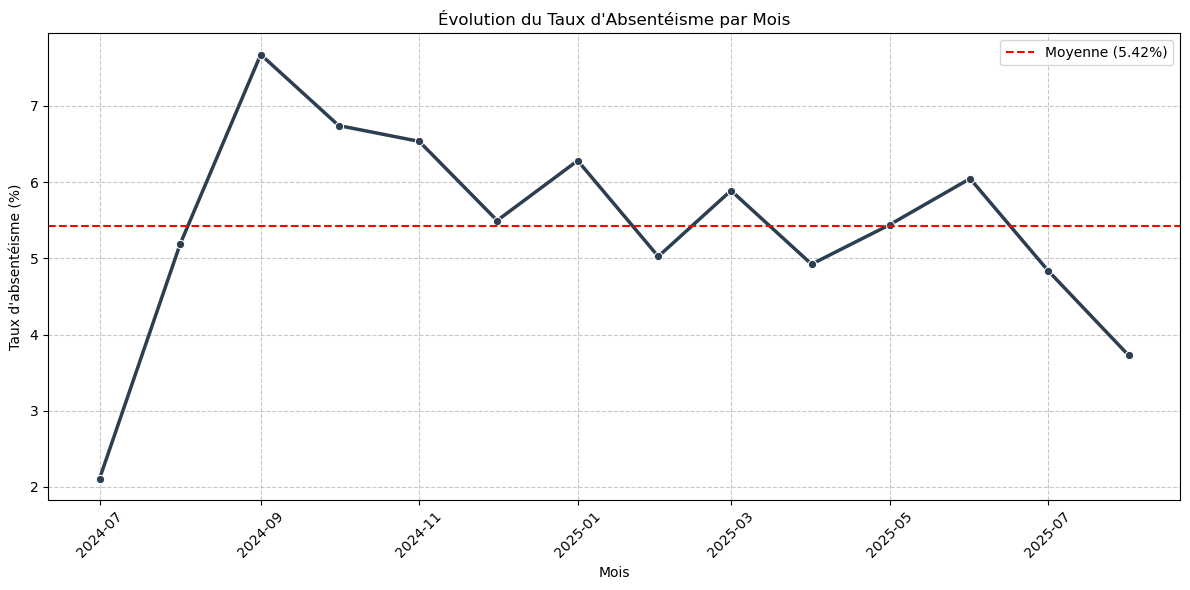

In [31]:
plt.figure(figsize=(12, 6))

absence_mois = absence_mois.sort_values('modalite')

sns.lineplot(data=absence_mois, x='modalite', y='taux_absenteisme', marker='o', linewidth=2.5, color='#2c3e50')

plt.title("Évolution du Taux d'Absentéisme par Mois")
plt.xlabel("Mois")
plt.ylabel("Taux d'absentéisme (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

moyenne = absence_mois['taux_absenteisme'].mean()
plt.axhline(moyenne, color='red', linestyle='--', label=f'Moyenne ({moyenne:.2f}%)')
plt.legend()

plt.tight_layout()
plt.show()

On remarque encore une fois un pique d'absentéisme au mois de septembre, on aimerait donc savoir quelle est la raison de ce fort taux d'absenteisme.

          type_absence  jours_ouvres        (%)
0              Maladie           613  44.842721
1   Congés d'éducation           412  30.138990
2  Accident de travail           263  19.239210
3        Enfant malade            24   1.755669
4                Décès            21   1.536211


/var/folders/p7/6d8yhyb548n9zytc57_yk00m0000gn/T/ipykernel_2421/2603845991.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sept.head(5), x='(%)', y='type_absence', palette='magma')


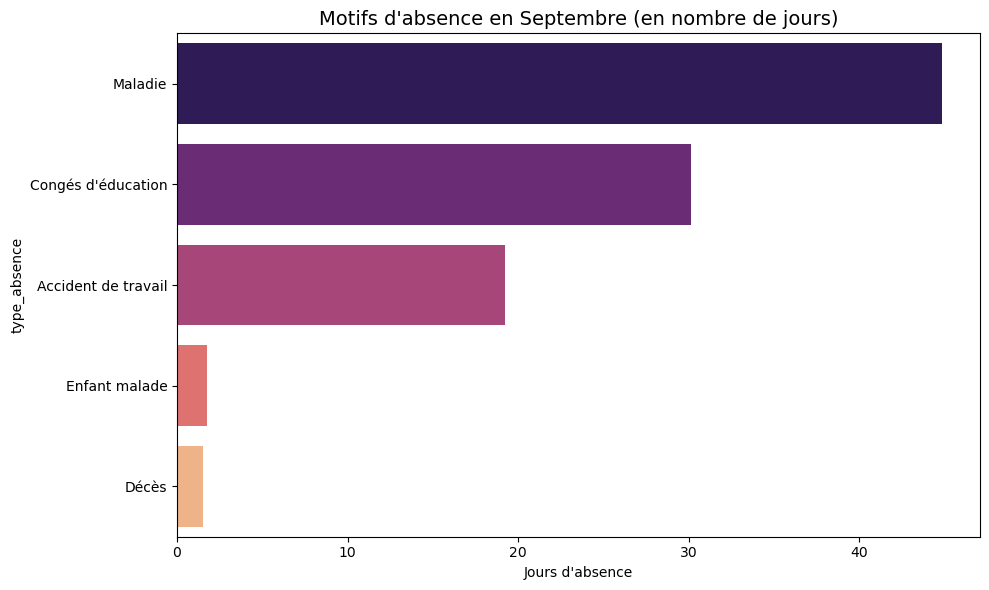

In [37]:
df_sept = absences_enrichies[absences_enrichies['mois'].dt.month == 9]

sept = df_sept.groupby('type_absence')['jours_ouvres'].sum().sort_values(ascending=False).reset_index()

total_jours_sept = sept['jours_ouvres'].sum()
sept['(%)'] = (sept['jours_ouvres'] / total_jours_sept) * 100

print(sept.head(5))

plt.figure(figsize=(10, 6))
sns.barplot(data=sept.head(5), x='(%)', y='type_absence', palette='magma')
plt.title("Motifs d'absence en Septembre (en nombre de jours)", fontsize=14)
plt.xlabel("Jours d'absence")
plt.tight_layout()
plt.show()

On voit que plus de 40% des absences totales sont dû à un arrêt maladie en septembre, cela peut être expliqué par la rentrée qui signifie à la fois une reprise d'activité intense mais aussi le retour des enfants à l'école et donc pour les employés qui sont parents, ils peuvent avoir besoin de s'absenter à cause d'une maladie attrapée par leurs enfants à l'école par exemple.

## Cartes de chaleur

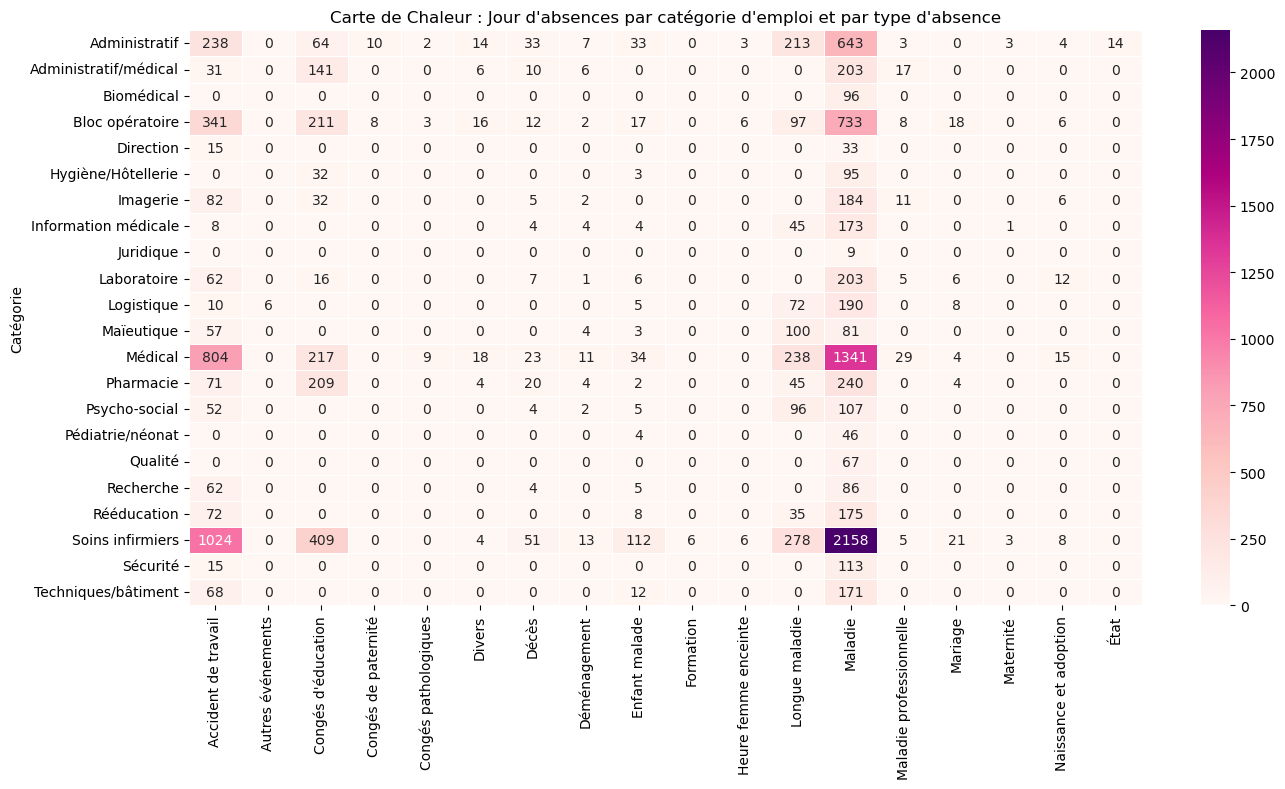

In [61]:
chaleur_data = absences_enrichies.groupby(['type_absence', 'catégorie'])['jours_ouvres'].sum().reset_index()

chaleur_matrice = chaleur_data.pivot(index='catégorie', columns='type_absence', values='jours_ouvres')

chaleur_matrice = chaleur_matrice.fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(chaleur_matrice, annot=True, fmt='.0f', cmap='RdPu', linewidths=.5)
plt.title("Carte de Chaleur : Jour d'absences par catégorie d'emploi et par type d'absence")
plt.ylabel("Catégorie")
plt.xlabel("")
plt.tight_layout()
plt.show()

On voit alors que les catégories qui ont le plus de jour d'absences sont les service dans le médical et les soins infirmiers en majorité pour des arrêts maladie mais nous avons vu que ce n'était pas les catégories avec le plus haut taux d'asentéisme, cela peut s'expliquer par le fait que les employes doivent être très nombreux dans ces services comparé au juridique (9 jours d'absences), à la sécurité (128 jours d'absence) et au psychosocial (266 jours d'absences) où il doit y avoir beaucoup moins d'employés.

Donc ce taux d'absentéisme élevé dans ces catégories était dû à un nombre d'employés faible qui étaient toutefois souvent absents suite à des arrêts maladie.

In [55]:
juridique_df = absences_enrichies[absences_enrichies['catégorie'] == 'Juridique']
inf_df = absences_enrichies[absences_enrichies['catégorie'] == 'Soins infirmiers']

df_absences = absences_enrichies.groupby(['catégorie'])['jours_ouvres'].sum().reset_index()
absences_jur = df_absences[df_absences['catégorie'] == 'Juridique']['jours_ouvres'].sum()
absences_inf = df_absences[df_absences['catégorie'] == 'Soins infirmiers']['jours_ouvres'].sum()

nb_jur = juridique_df['id_contrat'].nunique()
nb_inf = inf_df['id_contrat'].nunique()

print("Nombre d'employés dans le juridique :", nb_jur)
print("Nombre d''absences dans le juridique :", absences_jur)

print("Nombre d'employés en soins infirmiers :", nb_inf)
print("Nombre d'absences en soins infirmiers :", absences_inf)


Nombre d'employés dans le juridique : 2
Nombre d''absences dans le juridique : 9
Nombre d'employés en soins infirmiers : 260
Nombre d'absences en soins infirmiers : 4098


On voit donc que dans le juridique par exemple ils ne sont que 2 employés avec un nombre d'absences total 9 absences contre 260 employés en soins infirmiers avec un nombre total de 4098 absences.

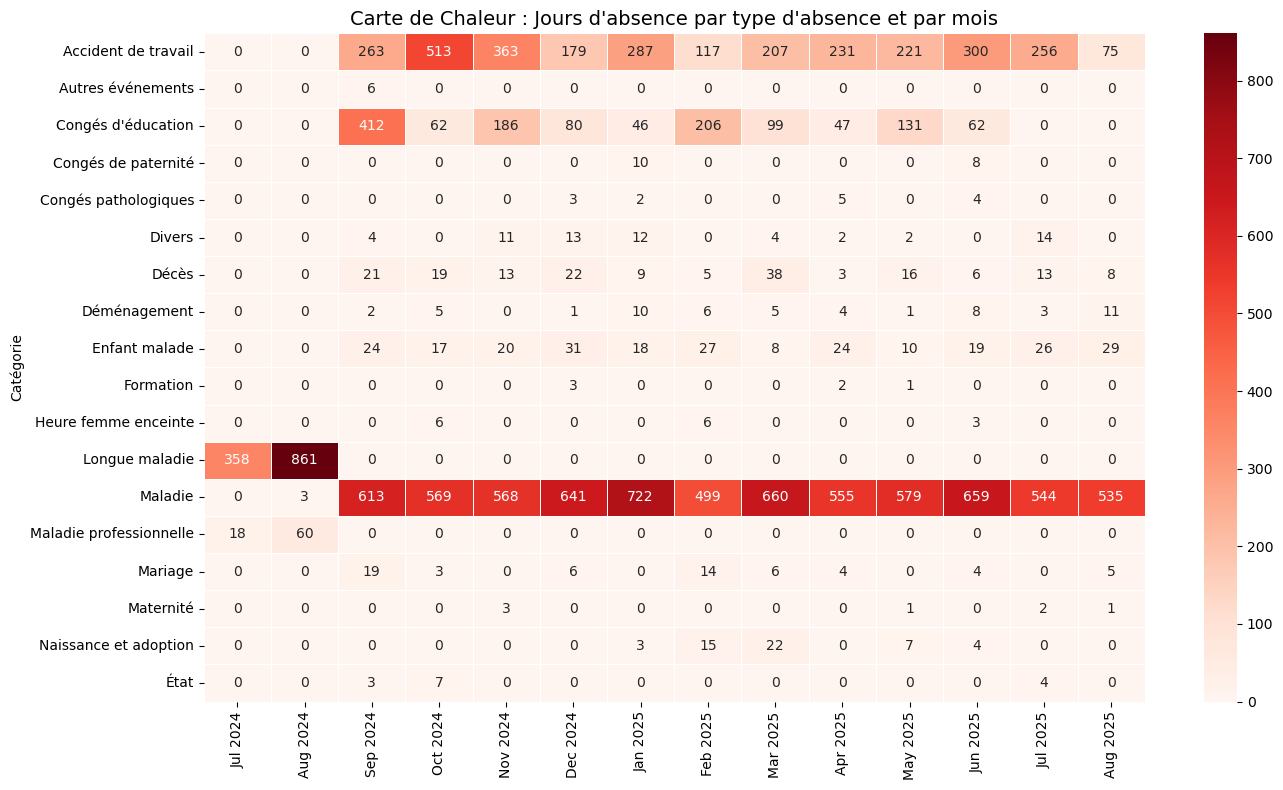

In [64]:
carte_data = absences_enrichies.groupby(['mois', 'type_absence'])['jours_ouvres'].sum().reset_index()

carte_matrice = carte_data.pivot(index='type_absence', columns='mois', values='jours_ouvres')

carte_matrice = carte_matrice.fillna(0)

carte_matrice.columns = [pd.to_datetime(c).strftime('%b %Y') for c in carte_matrice.columns]

plt.figure(figsize=(14, 8))
sns.heatmap(carte_matrice, annot=True, fmt='.0f', cmap='Reds', linewidths=.5)
plt.title("Carte de Chaleur : Jours d'absence par type d'absence et par mois", fontsize=14)
plt.ylabel("Catégorie")
plt.xlabel("")
plt.tight_layout()
plt.show()

On peut voir que tout au long de l'année la majorité des absences sont dues à des arrets maladie sauf en juillet et en aout où elles sont dues à des longues maladie.

Le haut taux d'absences en septembre est aussi du à des congés éducation, sûrement en rapport avec la rentrée scolaire 

## Différence entre la fréquence des absences et leur impact en jours perdus

Nous parlions dans l'étude du taux d'absentéisme par type d'absence du fait que les longues maladies sont moins fréquentes mais plus impactantes au niveau du taux d'absentéisme, nous pouvons étudier cela pour tous les types d'absences

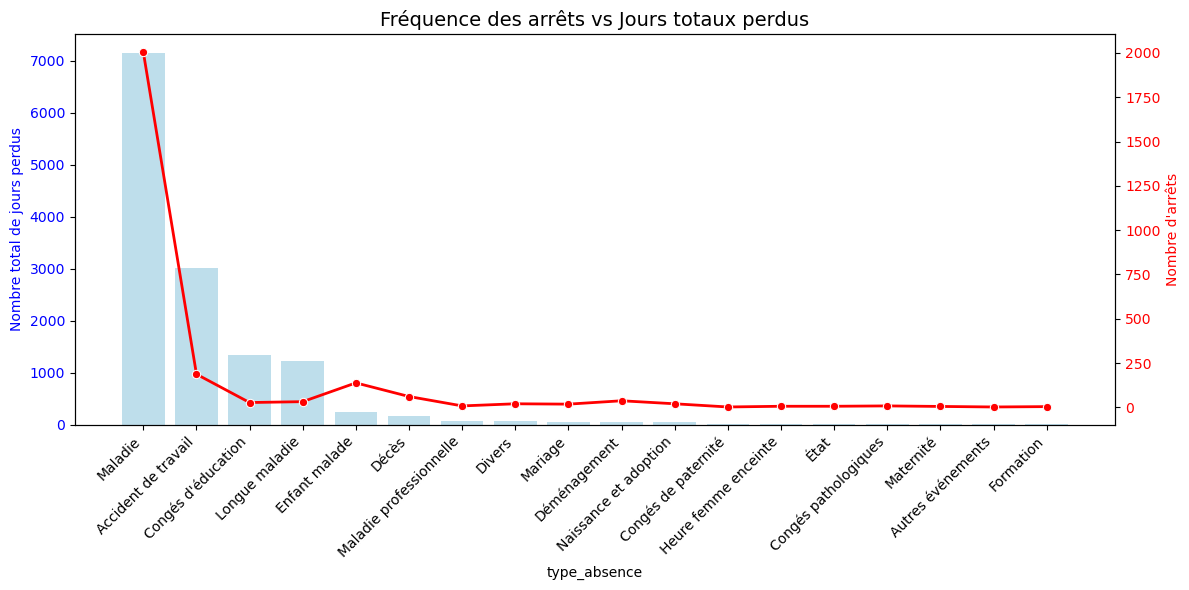

In [46]:
impact_abs = absences_enrichies.groupby('type_absence').agg(
    frequence=('id', 'count'),
    jours_perdus=('jours_ouvres', 'sum')
).reset_index()

impact_abs = impact_abs.sort_values('jours_perdus', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=impact_abs, x='type_absence', y='jours_perdus', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel("Nombre total de jours perdus", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
sns.lineplot(data=impact_abs, x='type_absence', y='frequence', color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel("Nombre d'arrêts", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Fréquence des arrêts vs Jours totaux perdus", fontsize=14)
plt.tight_layout()
plt.show()

On remarque que les absences pour arrêt maladie sont les plus dominantes, elles sont a la fois les plus fréquentes et les impactantes sur le nombre de jours perdus, et en constraste avec ce qu'on a vu dans l'étude des types d'absence, les longues maladies ont un fort impact mais sont moins fréquentes.

# Conclusion

Pour conclure, à partir de toutes ces données, on a pu voir que le type d'absences qui fait perdre le plus de jours de travail sont les arrêts maladie, ils sont à la fois fréquents et coûtent cher en jours perdus.

Les accidents de travail, les congés d'éducation et les longues maladies sont des types d'absences qui quant à eux sont beaucoup moins fréquents, mais très longs donc beaucoup de jours sont perdus.

Il faut bien prendre en compte les tailles des services lorsqu'on étudie les taux d'absentéisme car on a vu que le juridique par exemple avait un fort taux d'absentéisme mais il n'y a que 2 employés donc cela biaise nos résultats.
C'est pourquoi la carte de chaleur a été utile, elle nous a permis de voir quel catégorie d'emploi avait réellement un problème d'absentéisme et c'était en soins infirmiers où il y a une majorité d'arrêts maladie.
Cela peut être du premièrement à la forte charge de travail dans ces services,cela peut être aussi du au contact direct des infirmiers avec les patients malades et c'est aussi le service où il y a le plus d'accidents de travail ce qui n'est pas négligeable.

De plus, nous avons aussi vu que les arrêts maladie, les maladies professionnelles, les accidents de travail et les longues maladies sont en moyenne plus fréquents chez les plus de 40 ans. Cela peut être du à un environnement de travail qui n'est pas assez adapté à des personnes plus matures.

Enfin, nous avons aussi vu un pic de ces absences au mois de Septembre qui peut être expliqué par la rentrée scolaire et qui est présent dans plusieurs services.